# 🧠 MiniLLM v2.1 — notebook Colab (pour Kaggle : `MiniLLM_v2_Kaggle.ipynb`)

Un seul notebook, dans l'ordre. **Chaque cellule d'entraînement reprend toute seule** si la session a été coupée : il suffit de la relancer.

| # | Étape | Durée indicative |
|---|-------|------------------|
| 0 | Configuration + installation + GPU | 2 min |
| 1 | *(recommandé la 1re fois)* test de bon fonctionnement | 2 min |
| 2 | Corpus propre + tokenizer 32k + tokenisation | 20–60 min |
| 3 | Pré-entraînement | plusieurs heures (voir les `k tok/s` dans le log) |
| 4 | Données SFT (avec **personnalité**) + fine-tuning (questions → réponses) | 20–60 min |
| 5 | Évaluation, démo, mini-RAG, chat, export | 5 min |

💾 **Colab** : le code copie automatiquement les données sur le disque local avant l'entraînement (Drive est trop lent pour les lectures aléatoires) ; prévois environ 6 à 8 Go libres sur ton Drive (estimation).

⚠️ **Kaggle** : `/kaggle/working` ne survit pas à la session → à la fin, *Save Version* (ou ajoute la sortie précédente comme *Input*) et copie `BASE` si besoin. **Colab** : tout est stocké sur ton Google Drive.

## 0 · Configuration

In [5]:
import os, sys, subprocess, json, time

ON_COLAB  = "google.colab" in sys.modules
ON_KAGGLE = os.path.exists("/kaggle/working")

if ON_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    BASE, CODE_DIR = "/content/drive/MyDrive/MiniLLM_v2", "/content/minillm_v2"
elif ON_KAGGLE:
    BASE, CODE_DIR = "/kaggle/working/MiniLLM_v2", "/kaggle/working/minillm_v2"
else:
    BASE, CODE_DIR = os.path.abspath("MiniLLM_v2_workdir"), os.path.abspath(".")
os.makedirs(BASE, exist_ok=True)

REPO_URL = "https://github.com/bono-p/minillm_v2.git"
BRANCH   = "v2.1"       # "main" = v2 ; "v2.1" = nouvelle version (nettoyage renforcé, mini-RAG, garde-fous). Un run v2.1 repart de ZÉRO.

# ── Paramètres (modifie ici) ─────────────────────────────────────────────
MODEL_SIZE  = "49M"      # 13M | 23M | 49M | 110M ...  (noms = VRAI nombre de paramètres, vocab 32k)
WIKI_DOCS   = 450_000    # articles Wikipédia FR (nettoyés)          — 0 pour désactiver
WEB_DOCS    = 300_000    # documents FineWeb-2 FR (web, plus naturel) — 0 pour désactiver
VOCAB_SIZE  = 32_000

PT_ITERS    = 280_000     # ~655 M tokens ; le log affiche le nombre d'époques réel (corpus par défaut ≈ 340 M tokens -> ~2 époques)
PT_LR       = 6e-4       # 1e-3 pour 13M/23M, 6e-4 pour 49M, 3e-4 au-dessus de 110M
PT_BATCH    = 16         # par GPU ; baisse à 8 si "CUDA out of memory"
PT_TOKENS_PER_STEP = 65_536   # batch effectif visé (réparti automatiquement sur les GPU)
MAX_MINUTES = 660 if ON_KAGGLE else 0   # arrêt propre avant la limite de session (Kaggle : 12 h)

SFT_EPOCHS  = 1000
SFT_ALPACA, SFT_OASST, SFT_PIAF = 30_000, 3_000, 4_000
PERSONA_FILE, PERSONA_REPEAT = "personnalite.jsonl", 8    # personnalité (identité + caractère, PAS de faits) ; chaque Q/R est répétée 8x dans train
SFT_EXTRA, EXTRA_REPEAT = "", 3   # optionnel : dataset de faits à apprendre, ex. "datasets/faits_cameroun_afrique.jsonl" (sinon les faits passent par le RAG)
EXTRA_ARG = f"--extra_jsonl {SFT_EXTRA} --extra_repeat {EXTRA_REPEAT}" if SFT_EXTRA else ""

DATA   = f"{BASE}/data"
PT_OUT = f"{BASE}/checkpoints/pretrain"
SFT_OUT = f"{BASE}/checkpoints/sft"
print("BASE =", BASE)

import shutil
def local_copy(sub, refresh=False):
    """Colab : les données sont lues depuis le disque LOCAL (rapide) et non depuis Drive (lent en accès aléatoire).
    Les checkpoints, eux, restent sur Drive pour survivre aux coupures."""
    if not ON_COLAB:
        return f"{DATA}/{sub}"
    root, dst = "/content/minillm_local", f"/content/minillm_local/{sub}"
    os.makedirs(root, exist_ok=True)
    if refresh and os.path.exists(dst):
        shutil.rmtree(dst)
    if not os.path.exists(f"{dst}/meta.json"):
        print(f"Copie de {sub} sur le disque local…"); shutil.copytree(f"{DATA}/{sub}", dst)
    shutil.copy(f"{DATA}/tokenizer.json", f"{root}/tokenizer.json")
    return dst

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
BASE = /content/drive/MyDrive/MiniLLM_v2


In [2]:
# Installation + récupération du code (si le dossier existe déjà : simple mise à jour)
!pip -q install tokenizers datasets
if not os.path.exists(os.path.join(CODE_DIR, "train.py")):
    !git clone -b {BRANCH} {REPO_URL} {CODE_DIR}
elif os.path.exists(os.path.join(CODE_DIR, ".git")):
    !git -C {CODE_DIR} pull --ff-only
os.chdir(CODE_DIR); sys.path.insert(0, CODE_DIR)

import torch
N_GPU = torch.cuda.device_count()
print("GPU :", [torch.cuda.get_device_name(i) for i in range(N_GPU)] or "aucun (CPU : uniquement pour tester)")
if N_GPU:
    cap = torch.cuda.get_device_capability(0)
    print(f"Capacité de calcul {cap[0]}.{cap[1]} ->", "bf16 natif" if cap[0] >= 8 else "fp16 + GradScaler (T4/P100 : pas de bf16 natif ; le code choisit tout seul)")

PT_ACCUM = max(1, PT_TOKENS_PER_STEP // (PT_BATCH * 512 * max(1, N_GPU)))
print(f"Batch effectif : {PT_BATCH} x {PT_ACCUM} x {max(1, N_GPU)} GPU x 512 = {PT_BATCH * PT_ACCUM * max(1, N_GPU) * 512:,} tokens/pas")

Cloning into '/content/minillm_v2'...
remote: Enumerating objects: 342, done.
remote: Counting objects: 100% (187/187), done.
remote: Compressing objects: 100% (148/148), done.
remote: Total 342 (delta 103), reused 80 (delta 32), pack-reused 155 (from 1)
Receiving objects: 100% (342/342), 611.60 KiB | 7.74 MiB/s, done.
Resolving deltas: 100% (182/182), done.
GPU : ['Tesla T4']
Capacité de calcul 7.5 -> fp16 + GradScaler (T4/P100 : pas de bf16 natif ; le code choisit tout seul)
Batch effectif : 16 x 8 x 1 GPU x 512 = 65,536 tokens/pas


## 1 · Test de bon fonctionnement (recommandé la 1re fois, sans internet ni GPU)
Teste tout le pipeline sur un mini modèle : corpus → tokenizer → pré-entraînement → **reprise** → SFT → génération.

In [ ]:
!python smoke_test.py 2>&1 | tail -15

it    230/279 | loss 4.1744 | lr 3.44e-05 | gnorm 2.37 | 16.0k tok/s | 0.1M tok | 0.1 min | ETA 0.0 h
it    240/279 | loss 4.0763 | lr 2.93e-05 | gnorm 2.84 | 20.0k tok/s | 0.1M tok | 0.1 min | ETA 0.0 h
  ┌ EVAL it    240 | val_loss 4.1046 (ppl 60.6) | 2,239 tokens évalués | best 4.1046 ★ nouveau best
it    250/279 | loss 4.1853 | lr 2.53e-05 | gnorm 1.89 | 15.8k tok/s | 0.1M tok | 0.1 min | ETA 0.0 h
it    260/279 | loss 4.0324 | lr 2.24e-05 | gnorm 5.51 | 19.5k tok/s | 0.1M tok | 0.1 min | ETA 0.0 h
  ┌ EVAL it    260 | val_loss 4.0825 (ppl 59.3) | 2,239 tokens évalués | best 4.0825 ★ nouveau best
it    270/279 | loss 4.2232 | lr 2.06e-05 | gnorm 2.21 | 16.0k tok/s | 0.1M tok | 0.1 min | ETA 0.0 h
it    279/279 | loss 4.2488 | lr 2.00e-05 | gnorm 2.23 | 18.4k tok/s | 0.1M tok | 0.1 min | ETA 0.0 h
  ┌ EVAL it    279 | val_loss 4.0648 (ppl 58.3) | 2,239 tokens évalués | best 4.0648 ★ nouveau best
✅ terminé à it=279 | meilleure val_loss=4.0648 -> /tmp/tmpp_o9dfnf/ckpt_sft/best.pt

▶ 6

## 2 · Corpus propre → tokenizer → binaires
* Wikipédia FR **nettoyé** (les phrases « trouées » du dump, du type *« né le  à Moulins »*, sont supprimées) + web FR optionnel.
* Split train/val **par document**, `<|endoftext|>` entre les documents.
* Tokenizer BPE 32k entraîné **sur ton corpus** (2–3× moins de paramètres d'embedding que cl100k).

In [3]:
if os.path.exists(f"{DATA}/pretrain/meta.json"):
    print("✓ Données déjà prêtes :", json.load(open(f"{DATA}/pretrain/meta.json")))
else:
    !python prepare_data.py all --out {DATA} --wiki_docs {WIKI_DOCS} --web_docs {WEB_DOCS} --vocab_size {VOCAB_SIZE}

✓ Données déjà prêtes : {'dtype': 'uint16', 'vocab_size': 32000, 'padded_vocab_size': 32000, 'eot_id': 0, 'n_train_tokens': 3226198113, 'n_val_tokens': 32877678, 'n_train_docs': 4567182, 'n_val_docs': 46422, 'chars_per_token': 4.233, 'tokenizer': 'tokenizer.json', 'tokenizer_sha': '3cc94260f64a1ef2'}


## 3 · Pré-entraînement
* Relancer la cellule = **reprise exacte** (checkpoint complet toutes les 500 it, même ordre de données, même LR).
* `best.pt` = meilleure `val_loss` mesurée sur une **val fixe** → fiable. `final.pt` = dernière itération.
* 2 GPU (Kaggle T4×2) : lancé automatiquement avec `torchrun` (DDP).

In [ ]:
PT_DATA = local_copy("pretrain")     # Colab : copie unique sur le disque local
args = (f"--mode pretrain --data_dir {PT_DATA} --out_dir {PT_OUT} --model_size {MODEL_SIZE} "
        f"--seq_len 512 --batch_size {PT_BATCH} --grad_accum {PT_ACCUM} --lr {PT_LR} --min_lr {PT_LR/10} "
        f"--max_iters {PT_ITERS} --warmup_iters 300 --eval_every 500 --save_every 500 --eval_iters 50 "
        f"--max_minutes {MAX_MINUTES}")
if N_GPU > 1:
    !torchrun --standalone --nproc_per_node={N_GPU} train.py {args}
else:
    !python train.py {args}

════════════════════════════════════════════════════════════════════════
MiniLLM v2 — PRETRAIN | 49M (48.5M params, dont 32.1M hors embeddings)
device=cuda:0 dtype=torch.float16 GPU x1 compile=False | batch 16x8x1
Pré-entraînement : 65,536 tokens/it | 280000 it = 18350 M tokens (5.69 époque sur 3226 M tokens)
Reprise à it=15 | best_val_loss=inf
════════════════════════════════════════════════════════════════════════
it     25/280000 | loss 9.5742 | lr 5.00e-05 | gnorm 1.68 | 55.7k tok/s | 1.7M tok | 0.5 min | ETA 232.3 h | 7.5 Go GPU


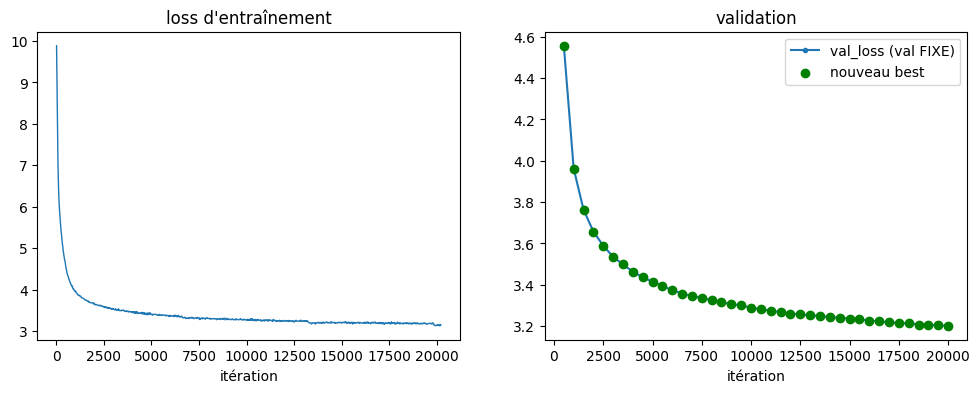

In [ ]:
# Courbes (lues dans log.jsonl : rapide, pas besoin de recharger les checkpoints)
import matplotlib.pyplot as plt
def plot_log(path):
    rows = [json.loads(l) for l in open(path)]
    tr = [(r["it"], r["loss"]) for r in rows if r["type"] == "train"]
    ev = [(r["it"], r["val_loss"], r["improved"]) for r in rows if r["type"] == "eval"]
    fig, ax = plt.subplots(1, 2, figsize=(12, 4))
    ax[0].plot(*zip(*tr), lw=1); ax[0].set_title("loss d'entraînement"); ax[0].set_xlabel("itération")
    ax[1].plot([e[0] for e in ev], [e[1] for e in ev], "o-", ms=3, label="val_loss (val FIXE)")
    ax[1].scatter([e[0] for e in ev if e[2]], [e[1] for e in ev if e[2]], c="green", zorder=3, label="nouveau best")
    ax[1].set_title("validation"); ax[1].set_xlabel("itération"); ax[1].legend(); plt.show()
plot_log(f"{PT_OUT}/log.jsonl")

In [ ]:
# Un texte de démonstration du modèle de base (il complète du texte, il ne répond pas aux questions : c'est normal)
!python generate.py --ckpt {PT_OUT}/best.pt --mode complete --prompt "La ville de Garoua est" --max_new 80

Modèle 49M | iter 20000 | val_loss 3.202404012680054 | device cpu
La ville de Garoua est la capitale de l'Oubangui-Chari, chef-lieu du département du Nyong-Kaï.

La ville est située à 53 km au sud-est de la capitale Garoua. Elle est le siège de la chefferie 32, et de la préfecture 10, elle possède 41,6km de la ville.

Le centre administratif de la commune est la 
[3.2s]


## 4 · Fine-tuning « questions → réponses »
Sources : Q/R synthétiques propres (hors-ligne) + French-Alpaca (réponses courtes) + OpenAssistant FR + PIAF (fenêtre centrée sur la réponse) + **`personnalite.jsonl`** (identité et caractère du modèle : nom, créateur, façon de parler ; les FAITS sont dans `knowledge/` et `datasets/`).
La loss ne porte **que sur les réponses** ; exemples jamais tronqués ; early stopping ; `best.pt` choisi sur la loss des réponses.

In [ ]:
# Si tu modifies personnalite.jsonl : supprime d'abord le dossier {DATA}/sft (ou change --out) pour reconstruire, puis ré-entraîne le SFT.
if os.path.exists(f"{DATA}/sft/meta.json"):
    print("✓ Données SFT déjà prêtes :", json.load(open(f"{DATA}/sft/meta.json"))["sources"])
else:
    !python sft_data.py --tokenizer {DATA}/tokenizer.json --out {DATA}/sft --alpaca {SFT_ALPACA} --oasst {SFT_OASST} --piaf {SFT_PIAF} --persona {PERSONA_FILE} --persona_repeat {PERSONA_REPEAT} {EXTRA_ARG}

Sources :
  ✓ synthetic          4,190 exemples
README.md: 100% 253/253 [00:00<00:00, 1.12MB/s]

Acquiesce_data_110k_instructions.json: downloading bytes:  16% 8.44M/52.0M [00:00<00:02, 16.6MB/s,  413kB/s  ]
Acquiesce_data_110k_instructions.json: downloading bytes: 100% 13.2M/13.2M [00:00<00:00, 16.2MB/s, 1.28MB/s  ]
Acquiesce_data_110k_instructions.json: reconstructing file: 100% 52.0M/52.0M [00:00<00:00, 63.8MB/s, 5.09MB/s  ]
Generating train split: 100% 110368/110368 [00:01<00:00, 93800.81 examples/s]
  ✓ french_alpaca     30,000 exemples
README.md: 100% 10.2k/10.2k [00:00<00:00, 28.5MB/s]

data/train-00000-of-00001-b42a775f407cee(…): downloading bytes:   0% 0.00/39.5M [00:00<?, ?B/s]
data/train-00000-of-00001-b42a775f407cee(…): downloading bytes:  71% 28.0M/39.5M [00:00<00:00, 44.5MB/s, 1.86MB/s  ]
data/train-00000-of-00001-b42a775f407cee(…): reconstructing file:  19% 7.69M/39.5M [00:00<00:03, 9.64MB/s,  367kB/s  ]
data/train-00000-of-00001-b42a775f407cee(…): downloading bytes:  95

In [ ]:
SFT_DATA = local_copy("sft", refresh=True)
!python train.py --mode sft --data_dir {SFT_DATA} --out_dir {SFT_OUT} --init_from {PT_OUT}/best.pt --epochs {SFT_EPOCHS}

Copie de sft sur le disque local…
ℹ️  reprise d'un checkpoint : init_from ignoré.
════════════════════════════════════════════════════════════════════════
MiniLLM v2 — SFT | 49M (48.5M params, dont 32.1M hors embeddings)
device=cpu dtype=torch.float32 GPU x1 compile=False | batch 16x2x1
SFT : 38,706 exemples | 1209 it/époque | 120900 it (100 époques)
Reprise à it=2000 | best_val_loss=2.1548
════════════════════════════════════════════════════════════════════════
it   2010/120900 | loss 1.3941 | lr 2.00e-04 | gnorm 3.23 | 25.6k tok/s | 4.3M tok | 2.8 min | ETA 558.4 h

⚠️  interruption : sauvegarde d'un checkpoint de reprise…


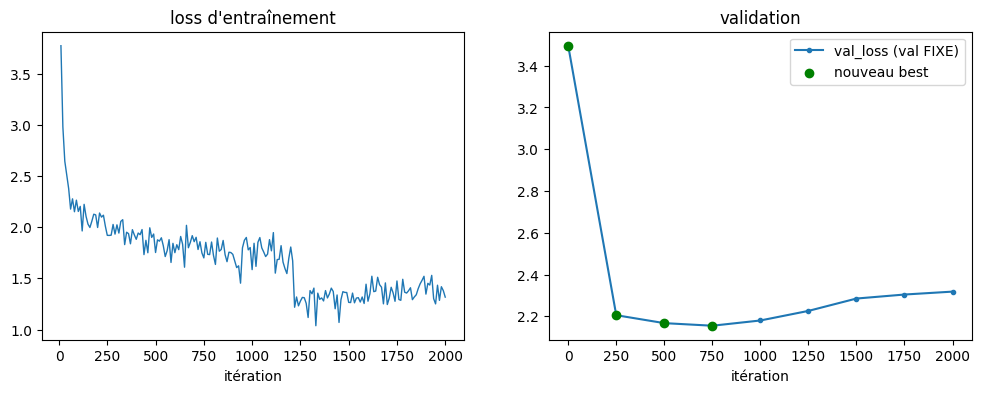

In [ ]:
plot_log(f"{SFT_OUT}/log.jsonl")

## 5 · Évaluation, démo, chat

In [ ]:
!python evaluate.py qa   --ckpt {SFT_OUT}/best.pt --sft_dir {DATA}/sft --n 500
!python evaluate.py demo --ckpt {SFT_OUT}/best.pt
!python evaluate.py persona --ckpt {SFT_OUT}/best.pt      # a-t-il appris personnalite.jsonl ?


Q : …Vérifie si la phrase suivante est grammaticalement correcte. Oui ou non ?  Je sais pas ou sont mes clés.
  attendu : Non
  obtenu  : Oui

Q : …18 plus 16 ?
  attendu : 18 plus 16 font 34.
  obtenu  : 18 plus 16 font 21.

Q : …Crée un court paragraphe décrivant l'importance des abeilles dans la pollinisation des cultures.
  attendu : Les abeilles jouent un rôle crucial dans la pollinisation des cultures, car elles sont responsables de la reproduction de nombreuses plantes
  obtenu  : Les abeilles sont des plantes qui peuvent être utilisées pour la pollinisation des cultures, tandis que les cultures incluent la tomate, le 

Q : …Fais une liste des éléments nécessaires pour planter un jardin aromatique à la maison.
  attendu : - Basilic - Romarin - Menthe - Coriandre - Thym - Persil - Ciboulette - Origan
  obtenu  : Les éléments nécessaires pour planter un jardin aromatique à la maison sont : - Lande - Arbre - Arbre - Arbre - Arbre - Arbre - Arbre - Arbr

Q : …Propose cinq idées de 

In [ ]:
# Mini-RAG (expérimental) : le modèle répond À PARTIR de ta base de connaissances (dossiers knowledge/ et datasets/ : .txt / .jsonl)
!python rag.py --ckpt {SFT_OUT}/best.pt --kb knowledge datasets --question "Quelle est la capitale du Cameroun ?"

267 passages indexés.

📄 Passage : La capitale du Cameroun est Yaoundé. Douala est la capitale économique et la plus grande ville du pays.
💬 Réponse : Kangui est la capitale économique et la plus grande ville du pays.


In [ ]:
!python evaluate.py openqa --ckpt {SFT_OUT}/best.pt --n 1000

MiniLLM v2 — OPEN QA / QUESTIONS SANS ATTENDU
Questions : 337

[1/337]
Q : Bonjour.
A : Bonjour, je t'écoute.
------------------------------------------------------------------------

[2/337]
Q : Salut, comment vas-tu ?
A : Ça va bien, merci de demander. Et toi ?
------------------------------------------------------------------------

[3/337]
Q : Qui es-tu ?
A : Je m'appelle MiniLLM. Je suis un petit modèle de langage créé par DevLab.
------------------------------------------------------------------------

[4/337]
Q : Comment t'appelles-tu ?
A : Appelle-moi MiniLLM. Tu peux aussi m'appeler Mini !
------------------------------------------------------------------------

[5/337]
Q : Que peux-tu faire ?
A : Je peux répondre à des questions simples, j'invente de petits textes et je discute volontiers en français.
------------------------------------------------------------------------

[6/337]
Q : Que ne peux-tu pas faire ?
A : Je peux répondre à des questions simples, j'invente de petit

In [ ]:
# Chat dans le notebook (modifie la question et relance la cellule)
from generate import load_model, chat_reply
model, tok, _ = load_model(f"{SFT_OUT}/best.pt")
history = []
def ask(question, **kw):
    history.append({"role": "user", "content": question})
    answer = chat_reply(model, tok, history, max_new_tokens=100, temperature=0.6, top_k=40, top_p=0.9,
                        repetition_penalty=1.1, no_repeat_ngram=3, **kw)
    history.append({"role": "assistant", "content": answer})
    return answer
print(ask("Comment tu t'appelles ?"))      # personnalité (personnalite.jsonl)
print(ask("Qui t'a créé ?"))
print(ask("Quelle est la capitale du Cameroun ?"))

Je m'appelle MiniLLM. Je suis un petit modèle de langage créé par DevLab.
J'ai été créé par DevLab.
La capitale du Cameroun est Bangui.


In [ ]:
# Export : modèle + tokenizer dans un zip à télécharger
import shutil
os.makedirs(f"{BASE}/export", exist_ok=True)
for f in ("best.pt", "tokenizer.json"):
    shutil.copy(f"{SFT_OUT}/{f}", f"{BASE}/export/{f}")
print(shutil.make_archive(f"{BASE}/minillm_export", "zip", f"{BASE}/export"))

## Dépannage rapide
* **CUDA out of memory** → `PT_BATCH = 8` (le batch effectif reste identique, l'accumulation s'ajuste toute seule).
* **Loss non finie** → baisse `PT_LR` de 30 %, relance (reprise automatique depuis le dernier checkpoint).
* **Session coupée** → relance simplement la même cellule : elle reprend à la dernière sauvegarde.
* **torchrun bloque sur Kaggle T4×2** → dans une cellule : `os.environ["NCCL_P2P_DISABLE"] = "1"` puis relance ; sinon `N_GPU = 1`.
* Le modèle répète en boucle → c'est le défaut n°1 des petits modèles : `no_repeat_ngram=3` et `repetition_penalty=1.1` sont déjà actifs ; baisse `temperature` (0.3–0.5).